<a href="https://colab.research.google.com/github/Ayu-sshhhhh/Food-Vision-Classifier/blob/main/Binary%20Food%20Vision%20Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing necessary libraries

In [51]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn as sk
import keras as ks
import matplotlib.pyplot as plt
import seaborn as sns

print("Tensorflow version :", tf.__version__)
print("Pandas version :", pd.__version__)
print("Numpy version :", np.__version__)
print("Keras Version :", ks.__version__)
print("Scikit-learn version :", sk.__version__)
print("Seaborn version :", sns.__version__)

Tensorflow version : 2.19.0
Pandas version : 2.2.2
Numpy version : 2.0.2
Keras Version : 3.13.2
Scikit-learn version : 1.6.1
Seaborn version : 0.13.2


# Getting our data ready


In [52]:
import zipfile
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# Unzip the file
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

--2026-04-08 09:19:50--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.20.207, 108.177.98.207, 74.125.135.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.20.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip.1’

pizza_steak.zip.1   100%[===================>] 104.47M   326MB/s    in 0.3s    

2026-04-08 09:19:50 (326 MB/s) - ‘pizza_steak.zip.1’ saved [109540975/109540975]



## Inspect the data

In [53]:
!ls pizza_steak

test  train


In [54]:
!ls pizza_steak/train

pizza  steak


In [55]:
!ls pizza_steak/train/steak


1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [56]:
import os
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak/train'.
There are 0 directories and 750 images in 'pizza_steak/train/steak'.
There are 0 directories and 750 images in 'pizza_steak/train/pizza'.
There are 2 directories and 0 images in 'pizza_steak/test'.
There are 0 directories and 250 images in 'pizza_steak/test/steak'.
There are 0 directories and 250 images in 'pizza_steak/test/pizza'.


In [57]:
# another way tp find out how many imagse are there in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))

num_steak_images_train

750

In [58]:
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  target_folder = target_dir+target_class

  random_image = random.sample(os.listdir(target_folder), 1)
  print(random_image)
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"Image Shapes: {img.shape}")

  return img

['2467990.jpg']
Image Shapes: (512, 512, 3)


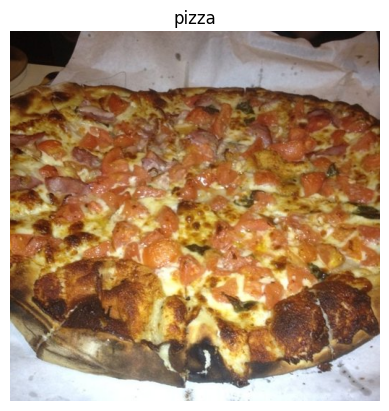

In [59]:
# View a random image from the training data
img = view_random_image(target_dir="pizza_steak/train/",
                        target_class="pizza")

In [60]:
img.dtype

dtype('uint8')

In [61]:
if(img.shape == (512,512,3)):
  print(True)
else:
  print(False)

True


# A CNN model

In [62]:
from keras.src.legacy.preprocessing.image import ImageDataGenerator
tf.random.set_seed(42)

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

train_data = train_datagen.flow_from_directory(directory = train_dir,
                                               batch_size = 32,
                                               target_size = (224,224),
                                               class_mode = "binary",
                                               seed = 42)
valid_data = valid_datagen.flow_from_directory(directory = test_dir,
                                               batch_size = 32,
                                               target_size = (224,224),
                                               class_mode = "binary",
                                               seed = 42)
# A typical CNN model
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters = 10,
                           kernel_size = 3, activation="relu",
                           input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10,3,activation = "relu"),
    tf.keras.layers.MaxPool2D(pool_size = 2,
                              padding = "valid"),
    tf.keras.layers.Conv2D(10,3,activation = "relu"),
    tf.keras.layers.Conv2D(10,3,activation = "relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compiling our CNN model
model_1.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5,
                        steps_per_epoch = len(train_data),
                        validation_data = valid_data,
                        validation_steps = len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.7247 - loss: 0.5504 - val_accuracy: 0.8340 - val_loss: 0.4391
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.8020 - loss: 0.4554 - val_accuracy: 0.8240 - val_loss: 0.3992
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.8060 - loss: 0.4351 - val_accuracy: 0.8480 - val_loss: 0.3765
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.8200 - loss: 0.4144 - val_accuracy: 0.8400 - val_loss: 0.3727
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.8453 - loss: 0.3628 - val_accuracy: 0.8460 - val_loss: 0.3410


**Note :** if the cell takes more than 10 secs, use GPU instead of using the typical runtime type.

### CNN Model summary

In [63]:
model_1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

# The basic model

In [64]:
# Using our model built before (image classifier (sample data)) on this data

tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model_2.compile(loss="binary_crossentropy",
               optimizer="Adam",
               metrics=["accuracy"])

history_2 = model_2.fit(train_data,
                        validation_data=valid_data,
                        epochs=5,
                        steps_per_epoch = len(train_data),
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.4860 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.4707 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.4840 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931


### Basic model summary

In [65]:
model_2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

# Basic Model with more neurons

In [66]:
tf.random.set_seed(42)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_3.compile(loss="binary_crossentropy",
                optimizer = "Adam",
                metrics = ["accuracy"])

history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch = len(train_data),
                        validation_data = valid_data,
                        validation_steps = len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.6227 - loss: 4.0565 - val_accuracy: 0.6920 - val_loss: 0.9007
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.6873 - loss: 1.0348 - val_accuracy: 0.6760 - val_loss: 1.1120
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.6667 - loss: 1.0392 - val_accuracy: 0.7800 - val_loss: 0.5570
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.7493 - loss: 0.5554 - val_accuracy: 0.7940 - val_loss: 0.4577
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.7747 - loss: 0.4907 - val_accuracy: 0.7940 - val_loss: 0.4478


### Basic model with more neurons summary

In [67]:
model_3.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

# Binary Classification

1. Visualize
2. Preprocess the data
3. Create a model
4. Fit the model
5. Evaluate the model
6. Hyperparameter tuning
7. Repeat until satisfied

## Visualize our data

['3478318.jpg']
Image Shapes: (512, 512, 3)
['2365046.jpg']
Image Shapes: (512, 512, 3)


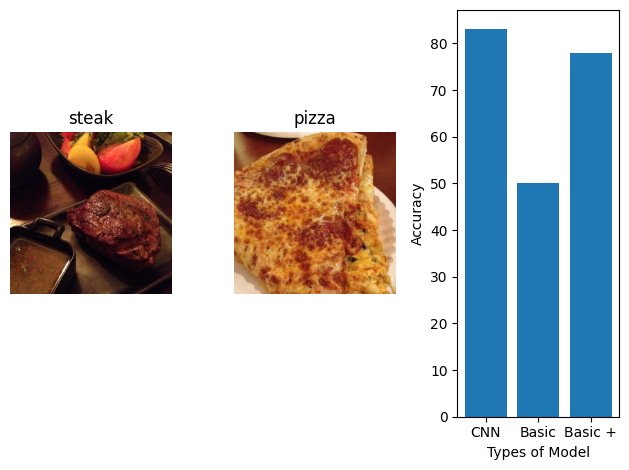

In [68]:
plt.figure()
plt.subplot(1,3,1)
steak_img = view_random_image("pizza_steak/train/", "steak")
plt.subplot(1,3,2)
pizza_img = view_random_image("pizza_steak/train/", "pizza")
ax = plt.subplot(1,3,3)
model_performance = {"CNN" :83 , "Basic" : 50, "Basic +" : 78}
ax.bar(x = model_performance.keys(), height = model_performance.values())
ax.set(xlabel="Types of Model", ylabel="Accuracy")
plt.tight_layout()
plt.show()

## Preprocess the data

In [69]:
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

### turning data into batches

In [70]:
from keras.src.legacy.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               target_size=(224,224),
                                               class_mode='binary',
                                               batch_size=32)
test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(224,224),
                                             class_mode='binary',
                                             batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [71]:
images, labels = next(train_data)
print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32,)


## Create a CNN model

In [72]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential
import warnings
warnings.filterwarnings("ignore")

model_4 = Sequential([
    Conv2D(filters=10,
           kernel_size=(3,3), strides=(1,1),
           padding="valid",
           activation="relu",
           input_shape=(224,224,3)),
    Conv2D(10,3,activation="relu"),
    Conv2D(10,3,activation="relu"),
    Flatten(),
    Dense(1, activation="sigmoid")
])

## Compile the model


In [73]:
from keras.src import optimizers
model_4.compile(loss='binary_crossentropy',
                optimizer='Adam',
                metrics=['accuracy'])

In [74]:
model_4.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 218, 218, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 475240)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │       475,241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,341 (1.82 MB)

 Trainable params: 477,341 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

## Fit the model

In [75]:
history_4 = model_4.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data),
                        verbose=2)

Epoch 1/5
47/47 - 9s - 198ms/step - accuracy: 0.6987 - loss: 0.7442 - val_accuracy: 0.7900 - val_loss: 0.4492
Epoch 2/5
47/47 - 5s - 105ms/step - accuracy: 0.8053 - loss: 0.4232 - val_accuracy: 0.8520 - val_loss: 0.3692
Epoch 3/5
47/47 - 5s - 112ms/step - accuracy: 0.8627 - loss: 0.3453 - val_accuracy: 0.8640 - val_loss: 0.3610
Epoch 4/5
47/47 - 5s - 107ms/step - accuracy: 0.9300 - loss: 0.2074 - val_accuracy: 0.8240 - val_loss: 0.3704
Epoch 5/5
47/47 - 5s - 103ms/step - accuracy: 0.9713 - loss: 0.0955 - val_accuracy: 0.8360 - val_loss: 0.3653


## Evaluating our model

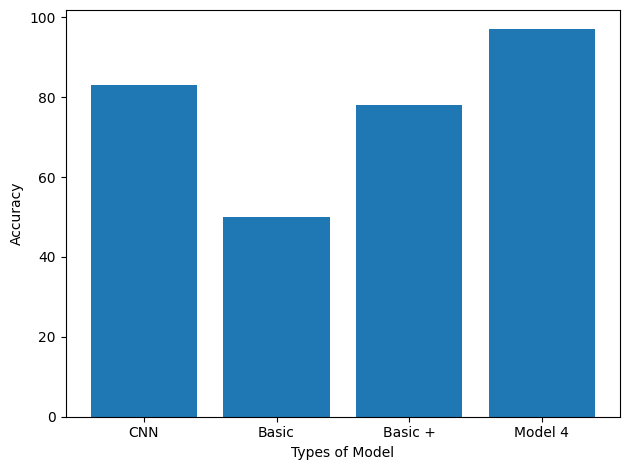

In [76]:
plt.figure()
ax = plt.subplot(1,1,1)
model_performance = {"CNN" :83 , "Basic" : 50, "Basic +" : 78, "Model 4":97}
ax.bar(x = model_performance.keys(), height = model_performance.values())
ax.set(xlabel="Types of Model", ylabel="Accuracy")
plt.tight_layout()
plt.show()

In [77]:
model_1_score = model_1.evaluate(test_data)
model_2_score = model_2.evaluate(test_data)
model_3_score = model_3.evaluate(test_data)
model_4_score = model_4.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8460 - loss: 0.3410
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5000 - loss: 0.6931
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.7940 - loss: 0.4478
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8360 - loss: 0.3653


In [78]:
model_4_score

[0.3652978539466858, 0.8360000252723694]

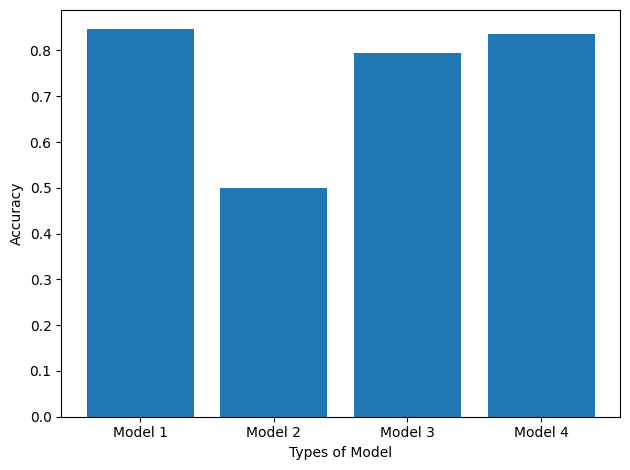

In [79]:
plt.figure()
ax = plt.subplot(1,1,1)
model_performance = {"Model 1" :model_1_score[1], "Model 2" : model_2_score[1], "Model 3":model_3_score[1], "Model 4" : model_4_score[1]}
ax.bar(x = model_performance.keys(), height = model_performance.values())
ax.set(xlabel="Types of Model", ylabel="Accuracy")
plt.tight_layout()
plt.show()

In [80]:
def plot_loss_curve(history):
  """
  Returns separate loss curves for training and validation matrix
  """
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]
  val_accuracy = history.history["val_accuracy"]
  accuracy = history.history["accuracy"]

  epochs = range(len(history.history["loss"]))

  # Plot Loss
  plt.figure()
  plt.plot(epochs, loss, label = "Training Loss")
  plt.plot(epochs, val_loss, label = "Val_Loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()
  # Plot Accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label = "Training Accuracy")
  plt.plot(epochs, val_accuracy, label = "Val_Accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Score")
  plt.legend()

### Loss, Accuracy curve for Model 4

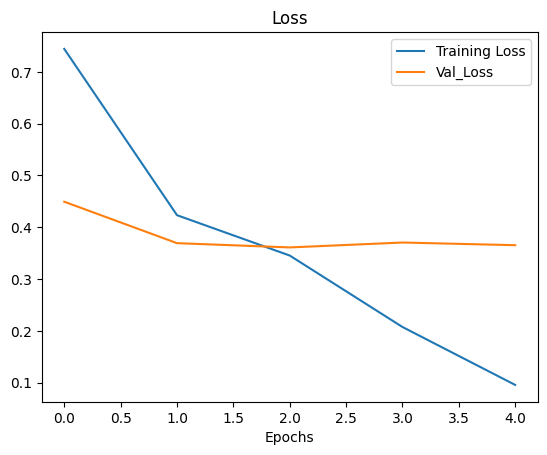

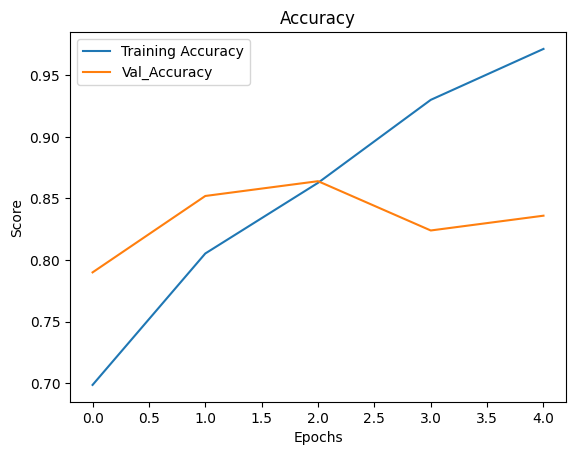

In [81]:
plot_loss_curve(history_4)

## New Model (with pooling)

In [82]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential
import warnings
warnings.filterwarnings("ignore")
model_5 = Sequential([
    Conv2D(10, 3, activation="relu", input_shape=(224,224,3)),
    MaxPool2D(),
    Conv2D(10,3,activation="relu"),
    MaxPool2D(),
    Conv2D(10,3,activation="relu"),
    MaxPool2D(),
    Conv2D(10,3,activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

In [83]:
model_5.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

In [84]:
history_5 = model_5.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data = test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - accuracy: 0.6007 - loss: 0.6606 - val_accuracy: 0.7860 - val_loss: 0.5309
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.7700 - loss: 0.4895 - val_accuracy: 0.8100 - val_loss: 0.4229
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.8073 - loss: 0.4373 - val_accuracy: 0.8280 - val_loss: 0.3699
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.8107 - loss: 0.4186 - val_accuracy: 0.8560 - val_loss: 0.3452
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.8067 - loss: 0.4148 - val_accuracy: 0.8720 - val_loss: 0.3391


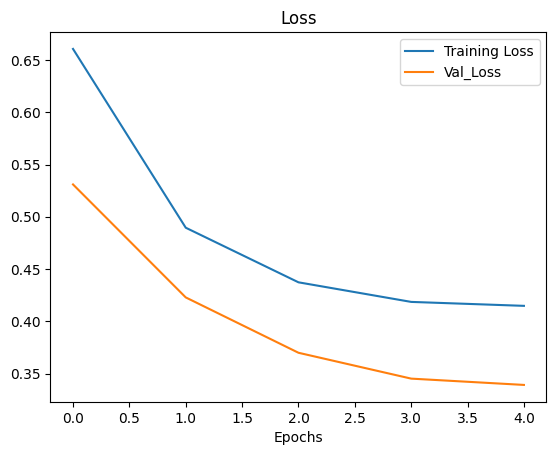

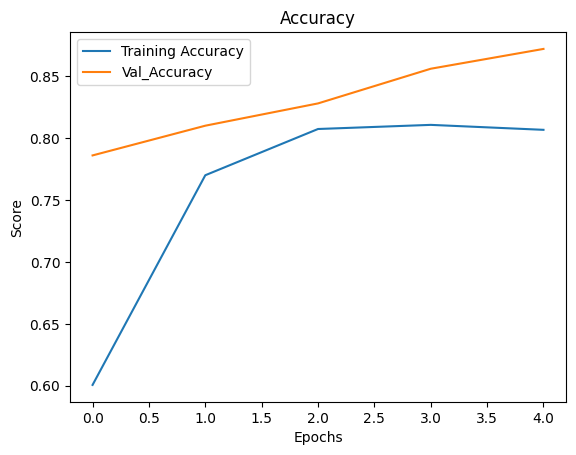

In [85]:
plot_loss_curve(history_5)

# Making predictions

In [86]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg

--2026-04-08 09:22:37--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘03-steak.jpeg.1’

03-steak.jpeg.1     100%[===================>]   1.89M  --.-KB/s    in 0.03s   

2026-04-08 09:22:37 (54.5 MB/s) - ‘03-steak.jpeg.1’ saved [1978213/1978213]



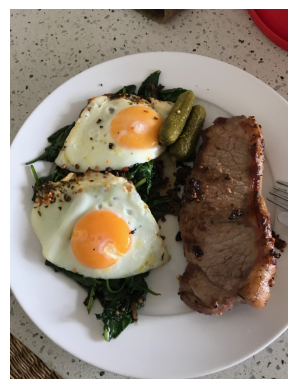

In [87]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
steak = mpimg.imread("03-steak.jpeg")
plt.imshow(steak)
plt.axis(False);

In [88]:
steak.shape

(4032, 3024, 3)

Preprocess the image

when making prediction with our own data, it is necessary for the image to be of the same format as the trained data

In [89]:
def load_and_prep_image(filename, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor and
  reshapes it to (img_shape, img_shape, colour channels)
  """
  img = tf.io.read_file(filename)
  img = tf.image.decode_image(img)
  img = tf.image.resize(img, size = [img_shape, img_shape])
  img = img/255
  return img

In [90]:
steak = load_and_prep_image("03-steak.jpeg")
steak

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.6377451 , 0.6220588 , 0.57892156],
        [0.6504902 , 0.63186276, 0.5897059 ],
        [0.63186276, 0.60833335, 0.5612745 ],
        ...,
        [0.52156866, 0.05098039, 0.09019608],
        [0.49509802, 0.04215686, 0.07058824],
        [0.52843136, 0.07745098, 0.10490196]],

       [[0.6617647 , 0.6460784 , 0.6107843 ],
        [0.6387255 , 0.6230392 , 0.57598037],
        [0.65588236, 0.63235295, 0.5852941 ],
        ...,
        [0.5352941 , 0.06862745, 0.09215686],
        [0.529902  , 0.05931373, 0.09460784],
        [0.5142157 , 0.05539216, 0.08676471]],

       [[0.6519608 , 0.6362745 , 0.5892157 ],
        [0.6392157 , 0.6137255 , 0.56764704],
        [0.65637255, 0.6269608 , 0.5828431 ],
        ...,
        [0.53137255, 0.06470589, 0.08039216],
        [0.527451  , 0.06862745, 0.1       ],
        [0.52254903, 0.05196078, 0.0872549 ]],

       ...,

       [[0.49313724, 0.42745098, 0.31029412],
        [0.05

In [91]:
pred = model_5.predict(tf.expand_dims(steak, axis=0))
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step


array([[0.8292642]], dtype=float32)

It currently outputs a prediction probability

Making it suiable to c=visualize the image as well as model's prediction

In [92]:
import tensorflow as tf

# Assuming 'train_data' is your dataset variable
train_data = tf.keras.preprocessing.image_dataset_from_directory("/content/pizza_steak/train")

# Define the variable here
class_names = train_data.class_names

print(class_names)
# Output should be: ['pizza', 'steak']

Found 1500 files belonging to 2 classes.
['pizza', 'steak']


In [93]:
print(class_names)

['pizza', 'steak']


In [94]:
pred_class = class_names[int(tf.round(pred))]
pred_class

'steak'

In [95]:
def pred_and_plot(model, filename, class_names=class_names):
  """
  Imports an image located at filenames, makes prediction with t=model
  and plots the image with predicted class as the title
  """
  img = load_and_prep_image(filename)
  pred = model.predict(tf.expand_dims(img, axis=0))
  pred_class = class_names[int(tf.round(pred))]
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


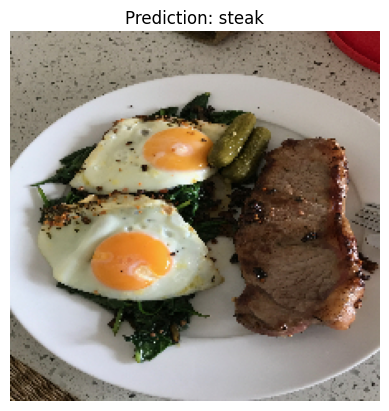

In [96]:
pred_and_plot(model_5, "03-steak.jpeg")